Лабораторная работа No 1\
«Разведочный анализ данных (EDA) и визуализация»\
Цель работы:\
Освоить полный цикл разведочного анализа данных (EDA): проверку базовых предполо-
жений измерительного процесса, расчёт описательных статистик, построение и интерпре-
тацию графиков (гистограмм, Box Plot, CDF, диаграмм рассеяния), выявление выбросов,
аномалий и взаимосвязей, а также формулирование гипотез для дальнейшего моделиро-
вания.\
Задачи:
1. Изучить философию и цели разведочного анализа данных
2. Освоить проверку четырёх фундаментальных предположений измерительного процесса
с помощью 4-Plot
3. Изучить меры центральной тенденции и меры разброса
4. Освоить построение и интерпретацию гистограмм, Box Plot, CDF и KDE
5. Изучить методы анализа взаимосвязей: диаграммы рассеяния и корреляции
6. Провести сравнительный анализ распределений по группам
7. Сформулировать гипотезы для дальнейшего моделирования

Исходные данные: Вариант 4: Iris — размеры цветков ириса

# Часть 1: Подготовка и первичный осмотр данных

In [22]:
import pandas as pd

df = pd.read_csv('Iris.csv')
df = df.drop(columns="Id")

print(f'Размерность данных: {df.shape}')

print('Первые 5 строк датасета')
display(df.head())
print('Последние 5 строк датасета')
display(df.tail())

print(f'Типы данных:\n{df.dtypes}')

Размерность данных: (150, 5)
Первые 5 строк датасета


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


Последние 5 строк датасета


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


Типы данных:
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species              str
dtype: object


In [23]:
print(f'Количество пропущенных значений по столбцам:\n{df.isna().sum()}')

print(f'Дубликаты:\n{df[df.duplicated(keep=False)]}')

Количество пропущенных значений по столбцам:
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64
Дубликаты:
     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm         Species
9              4.9           3.1            1.5           0.1     Iris-setosa
34             4.9           3.1            1.5           0.1     Iris-setosa
37             4.9           3.1            1.5           0.1     Iris-setosa
101            5.8           2.7            5.1           1.9  Iris-virginica
142            5.8           2.7            5.1           1.9  Iris-virginica


|Столбец|Тип|Шкала|Корректность среднего|
|:---:|:---:|:---:|:---:|
|SepalLengthCm|Количественные|Шкала отношений|+|
|SepalWidthCm|Количественные|Шкала отношений|+|
|PetalLengthCm|Количественные|Шкала отношений|+|
|PetalWidthCm|Количественные|Шкала отношений|+|
|Species|Категориальные|Номинальная|-|

В таблице 150 цветков ириса. Четыре числовых признака — размеры чашелистика и лепестка в сантиметрах, `Species` — вид цветка. После удаления служебного `Id` остаются 4 количественных признака и 1 категориальный. Пропусков нет. В выводе выше видно 5 строк, входящих в группы повторов; лишних копий среди них 2. Пока не удаляю их из основной таблицы `df`, чтобы сохранить исходную выборку для графиков.


# Часть 2: Проверка базовых предположений (4-Plot)

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

## 1. Построение Run Sequence Plot

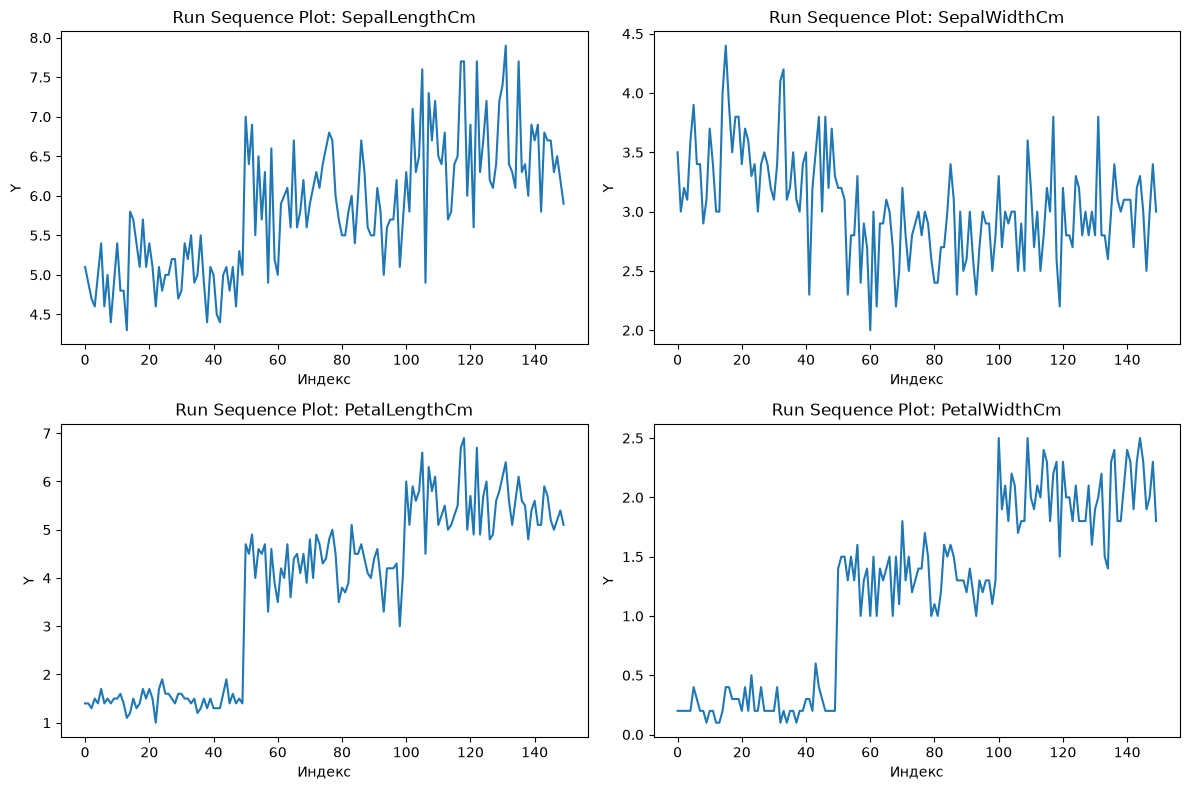

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
ax = axes.flat
for col in range(4):
    ax[col].plot(df[features[col]])
    ax[col].set_title(f'Run Sequence Plot: {features[col]}')
    ax[col].set_xlabel('Индекс')
    ax[col].set_ylabel('Y')
plt.tight_layout()
plt.show()

## 2. Построение Lag Plot

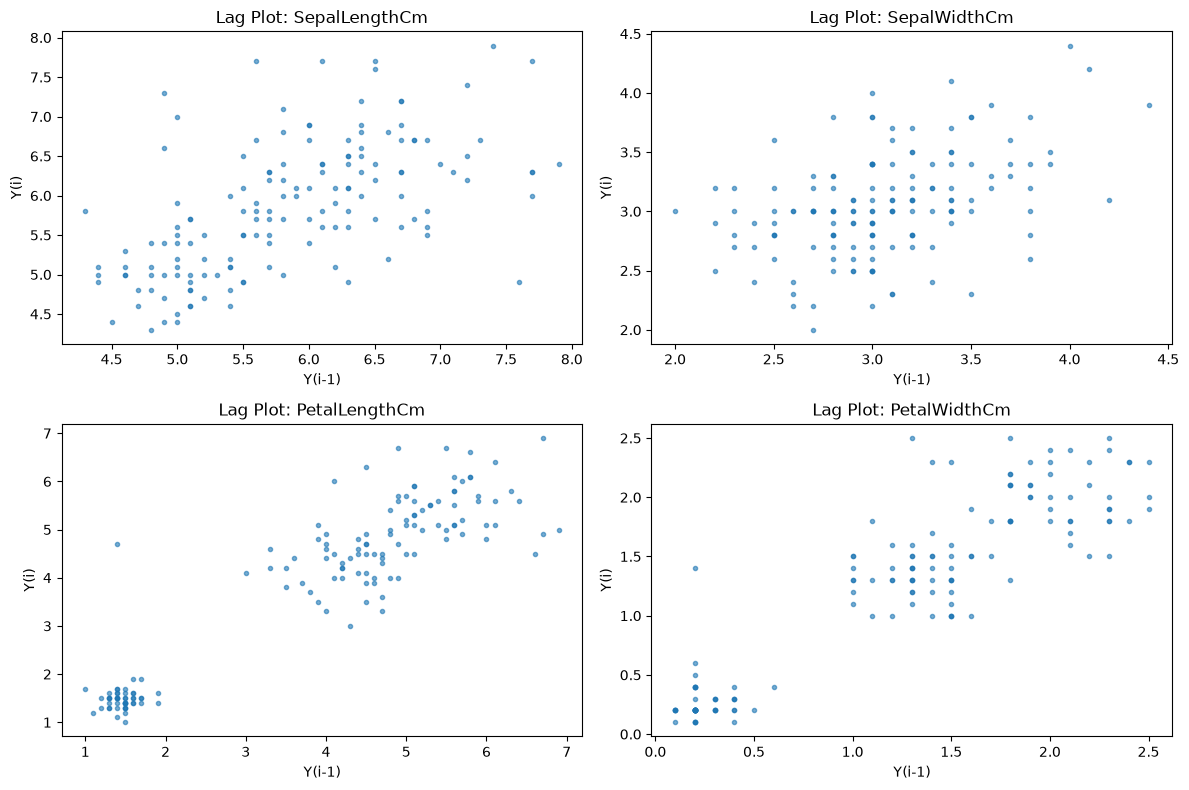

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
ax = axes.flat
for col in range(4):
    ax[col].plot(df[features[col]].values[:-1], df[features[col]].values[1:], '.', alpha=0.6)
    ax[col].set_title(f'Lag Plot: {features[col]}')
    ax[col].set_xlabel('Y(i-1)')
    ax[col].set_ylabel('Y(i)')
plt.tight_layout()
plt.show()

## 3. Построение гистограммы

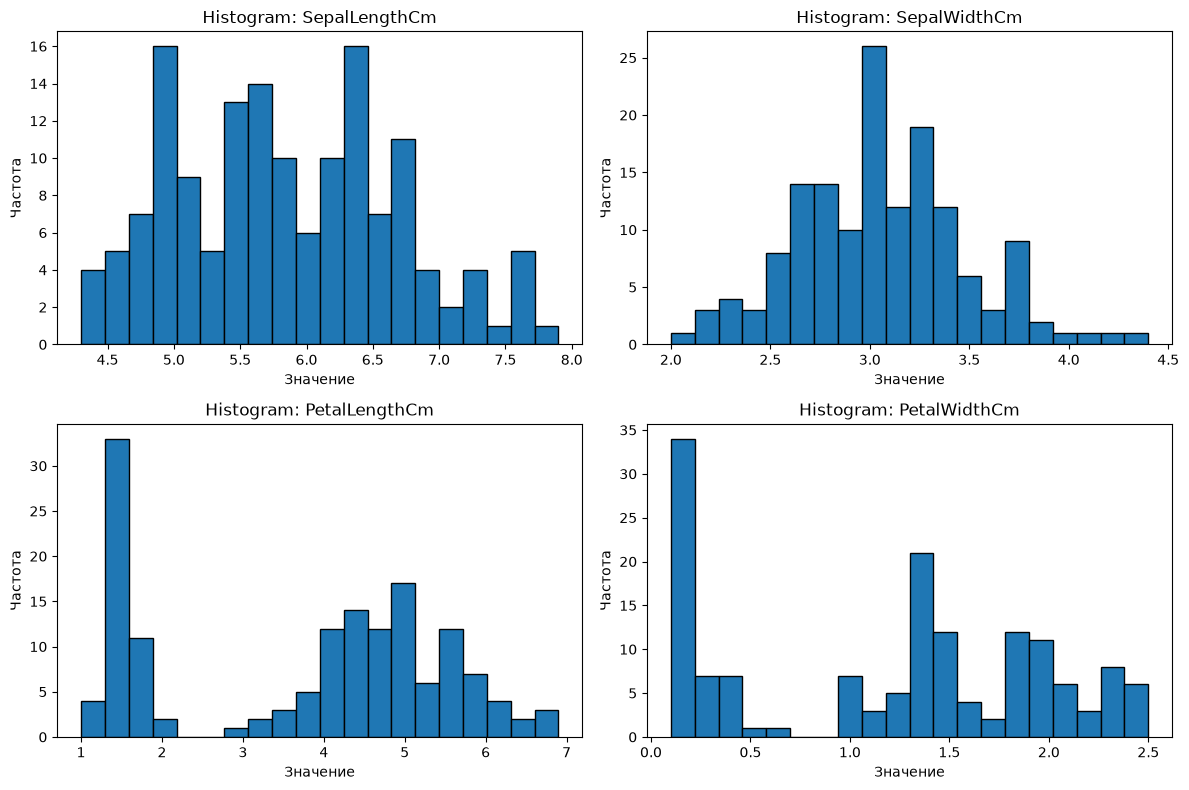

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
ax = axes.flat
for col in range(4):
    ax[col].hist(df[features[col]], bins=20, edgecolor='black')
    ax[col].set_title(f'Histogram: {features[col]}')
    ax[col].set_xlabel('Значение')
    ax[col].set_ylabel('Частота')
plt.tight_layout()
plt.show()

## 4. Построение Normal Probability Plot

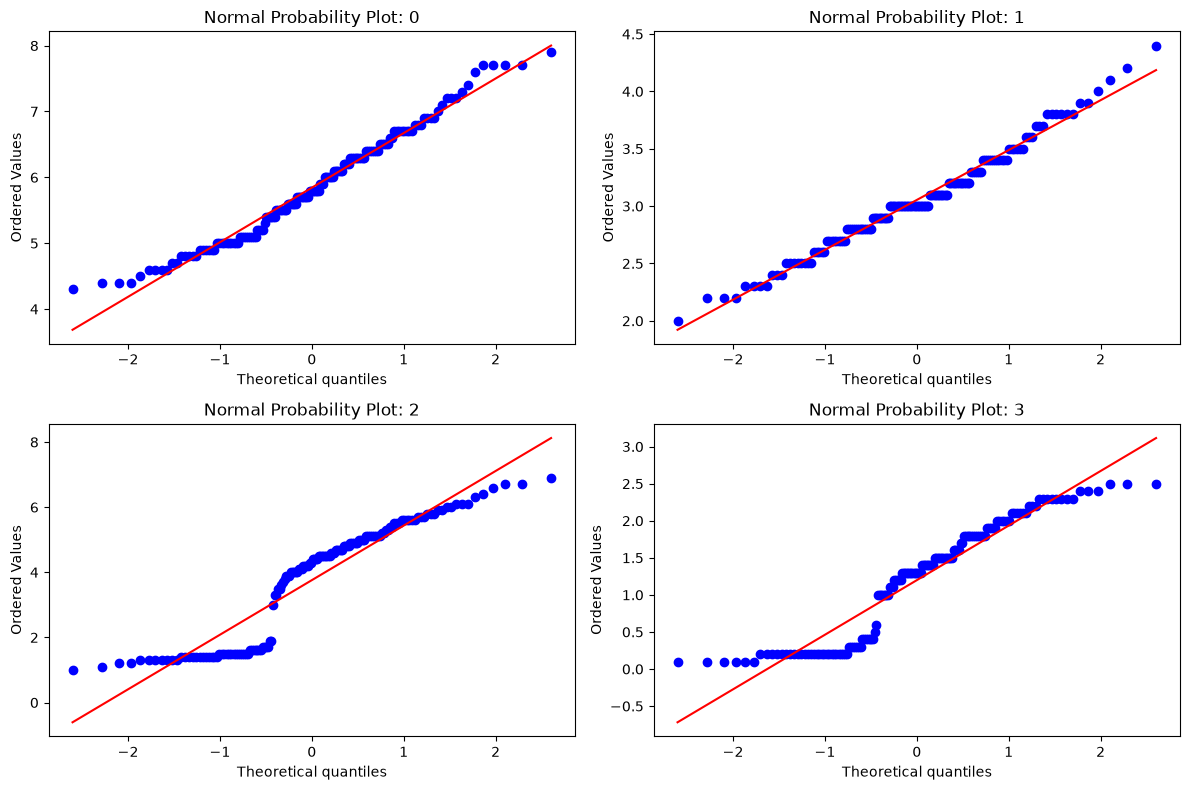

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
ax = axes.flat
for col in range(4):
    stats.probplot(df[features[col]], dist='norm', plot=ax[col])
    ax[col].set_title(f'Normal Probability Plot: {col}')
plt.tight_layout()
plt.show()

## 5. Интерпретация каждого графика и вывод о выполнении предположений

**Run Sequence Plot.** Уровни параметров меняются при переходе между группами видов. Это связано со структурой исходного набора, где виды расположены последовательно.

**Lag Plot.** Между соседними наблюдениями присутствует структура, частично обусловленная последовательным расположением объектов одного вида.

**Histogram.** Объединённое распределение не выглядит идеально нормальным; наличие трёх биологических групп влияет на форму распределения.

**Normal Probability Plot.** Отклонение точек от прямой показывает отличие объединённого распределения от нормального. Поэтому нормальность следует оценивать также отдельно внутри групп.

**Вывод о предположениях.** На Run Sequence Plot меняется уровень значений при переходе от одного вида к другому; постоянство положения для всей последовательности не подтверждается. Заметного плавного роста разброса по индексу нет, но разброс у видов может различаться. Lag Plot показывает зависимость соседних строк из-за порядка записи видов, поэтому считать эту последовательность случайной нельзя. Гистограммы и Q–Q-графики показывают, что распределение всех видов вместе не описывается одним нормальным законом. Индекс строки здесь не время наблюдения.


# Часть 3: Описательная статистика

In [29]:
rows = []
for col in features:
    s = df[col]
    rows.append({
        'Переменная': col,
        'Среднее': s.mean(),
        'Медиана': s.median(),
        'Мода': s.mode().iloc[0],
        'Дисперсия': s.var(),
        'Ст. откл.': s.std(),
        'IQR': s.quantile(.75) - s.quantile(.25),
        'MAD': (s - s.median()).abs().median(),
        'Размах': s.max() - s.min(),
        'CV, %': s.std() / s.mean() * 100
    })

pd.DataFrame(rows)


,Переменная,Среднее,Медиана,Мода,Дисперсия,Ст. откл.,IQR,MAD,Размах,"CV, %"
0,SepalLengthCm,5.843333,5.80,5.0,0.685694,0.828066,1.3,0.70,3.6,14.171126
1,SepalWidthCm,3.054000,3.00,3.0,0.188004,0.433594,0.5,0.25,2.4,14.197587
2,PetalLengthCm,3.758667,4.35,1.5,3.113179,1.764420,3.5,1.25,5.9,46.942721
3,PetalWidthCm,1.198667,1.30,0.2,0.582414,0.763161,1.5,0.70,2.4,63.667470


In [30]:
rows = []
for col in features:
    s = df[col]
    rows.append({
        'Переменная': col,
        'Среднее': s.mean(),
        'Медиана': s.median(),
        'Ассиметрия': s.skew(),
        'Эксцесс': s.kurt()
    })

pd.DataFrame(rows)

,Переменная,Среднее,Медиана,Ассиметрия,Эксцесс
0,SepalLengthCm,5.843333,5.80,0.314911,-0.552064
1,SepalWidthCm,3.054000,3.00,0.334053,0.290781
2,PetalLengthCm,3.758667,4.35,-0.274464,-1.401921
3,PetalWidthCm,1.198667,1.30,-0.104997,-1.339754


Среднее и медиана близки у обоих размеров чашелистика: 5,84 и 5,80 см для длины, 3,05 и 3,00 см для ширины. У лепестка разница больше: длина 3,76 против 4,35 см, ширина 1,20 против 1,30 см. Это согласуется с неоднородной формой общих распределений: в таблице смешаны три вида. Поэтому одно среднее для всех видов не всегда хорошо описывает типичный цветок. Наибольший относительный разброс по коэффициенту вариации — у ширины лепестка.


# Часть 4: Визуализация распределения

## 1. Построение гистограмм с различным числом бинов (столбцов)

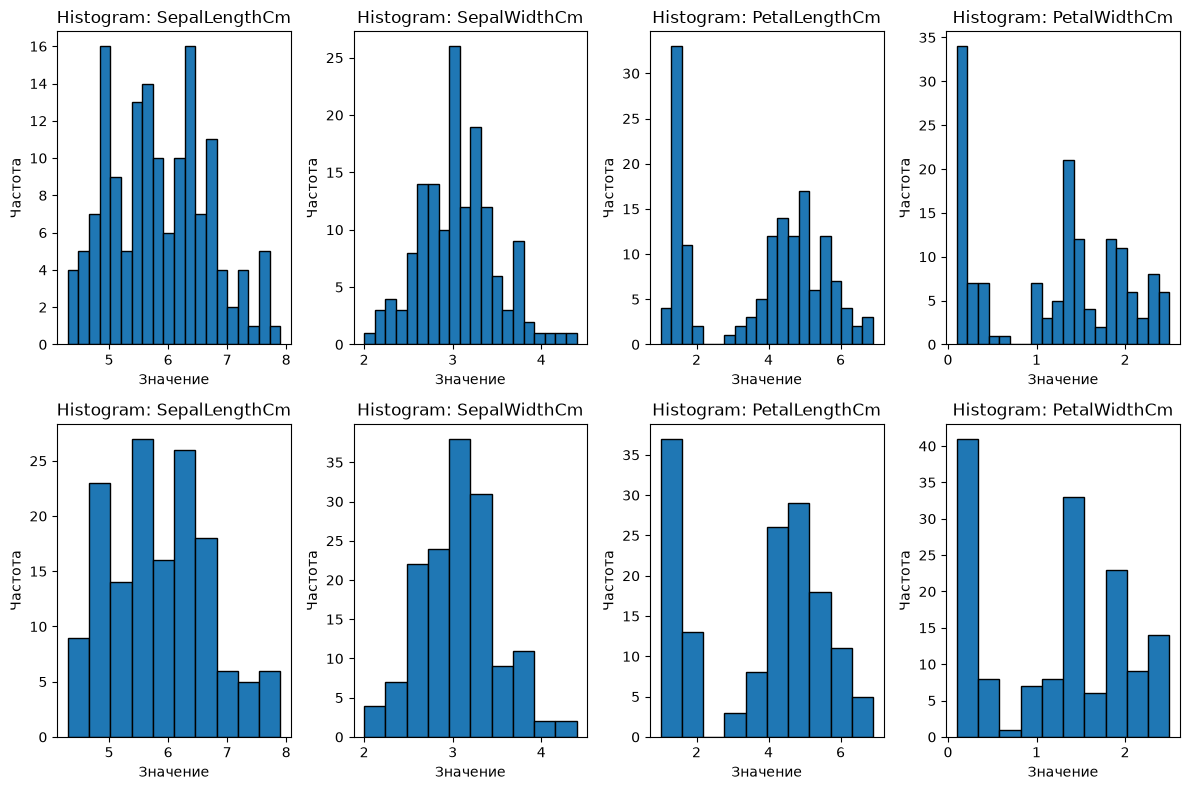

In [31]:
fig, axes = plt.subplots(2, 4, figsize=(12, 8))
ax = axes.flat

for col in range(4):
    ax[col].hist(df[features[col]], bins=20, edgecolor='black')
    ax[col].set_title(f'Histogram: {features[col]}')
    ax[col].set_xlabel('Значение')
    ax[col].set_ylabel('Частота')

for col in range(4):
    ax[col+4].hist(df[features[col]], bins=10, edgecolor='black')
    ax[col+4].set_title(f'Histogram: {features[col]}')
    ax[col+4].set_xlabel('Значение')
    ax[col+4].set_ylabel('Частота')

plt.tight_layout()
plt.show()

## 2. Построение Box Plot и обнаружение выбросов по правилу 1.5 ·IQR

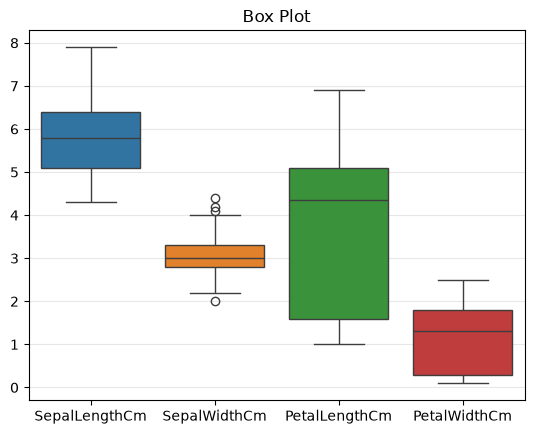

In [32]:
sns.boxplot(df[features])
plt.title('Box Plot')
plt.grid(axis='y', alpha=0.3)

plt.show()

In [33]:
outlier_mask = pd.Series(False, index=df.index)
outlier_rows = []

for col in features:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    mask = (df[col] < low) | (df[col] > high)
    outlier_mask = outlier_mask | mask
    outlier_rows.append({'Признак': col, 'Нижняя граница': low,
                         'Верхняя граница': high, 'За границами': mask.sum()})

display(pd.DataFrame(outlier_rows))
print(f'Строк с выбросом хотя бы по одному признаку: {outlier_mask.sum()}')
display(df.loc[outlier_mask, features + ['Species']])


,Признак,Нижняя граница,Верхняя граница,За границами
0,SepalLengthCm,3.15,8.35,0
1,SepalWidthCm,2.05,4.05,4
2,PetalLengthCm,-3.65,10.35,0
3,PetalWidthCm,-1.95,4.05,0


Строк с выбросом хотя бы по одному признаку: 4


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
15,5.7,4.4,1.5,0.4,Iris-setosa
32,5.2,4.1,1.5,0.1,Iris-setosa
33,5.5,4.2,1.4,0.2,Iris-setosa
60,5.0,2.0,3.5,1.0,Iris-versicolor


## 3. Построение CDF и нахождение процентилей

Процентили:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0.10,4.8,2.50,1.40,0.2
0.25,5.1,2.80,1.60,0.3
0.50,5.8,3.00,4.35,1.3
0.75,6.4,3.30,5.10,1.8
0.90,6.9,3.61,5.80,2.2


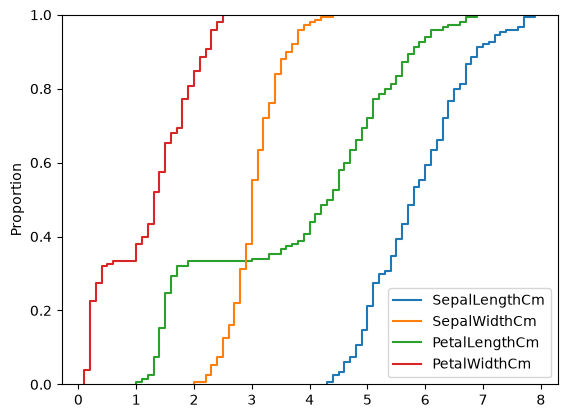

In [34]:
sns.ecdfplot(data=df)

print('Процентили:')
display(df[features].quantile([.10, .25, .50, .75, .90]))


ECDF показывает долю цветков со значением не выше выбранного. Например, медианная длина лепестка — 4,35 см: у половины наблюдений она не больше этого значения. По таблице видно, что центральные 50% значений длины лепестка лежат от 1,60 до 5,10 см; широкий интервал связан в том числе с различиями между видами.


## 4. Построение KDE и сравнение с гистограммой

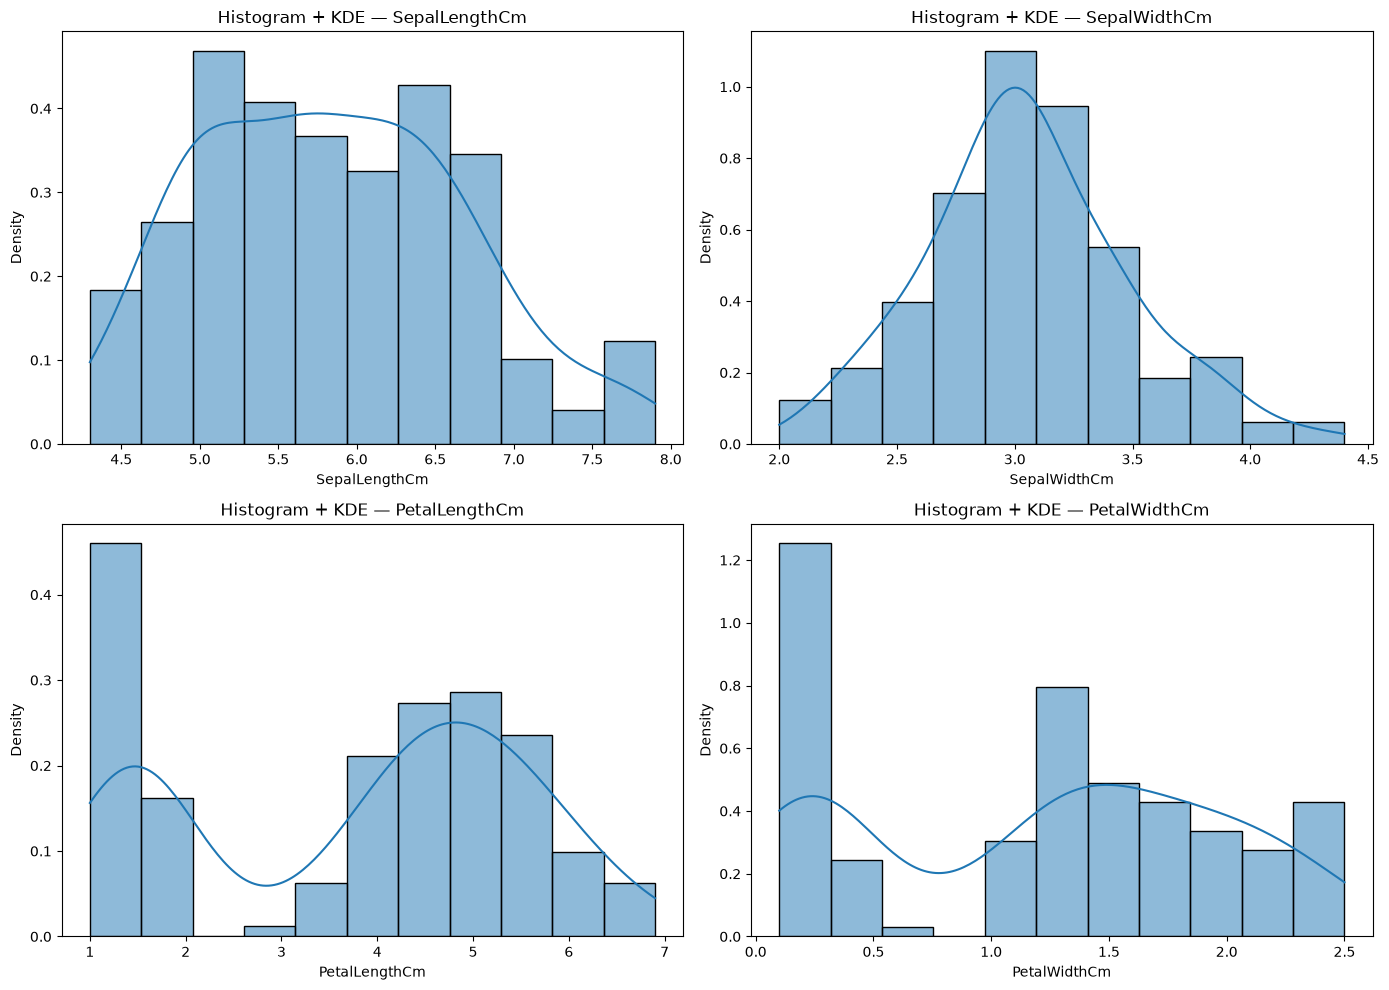

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax = axes.flat

for col in range(4):
    sns.histplot(data=df, x=features[col], bins="rice", stat='density', kde=True, ax=ax[col])
    ax[col].set_title(f'Histogram + KDE — {features[col]}')

plt.tight_layout()
plt.show()

Кривая KDE сглаживает столбики гистограммы. У размеров лепестка заметны отдельные области высокой плотности: объединение видов даёт распределение с несколькими группами значений. Число бинов меняет детали гистограммы, но не этот общий вывод.


# Часть 5: Анализ взаимосвязей

## 1. Построение диаграмм рассеяния с линией регрессии

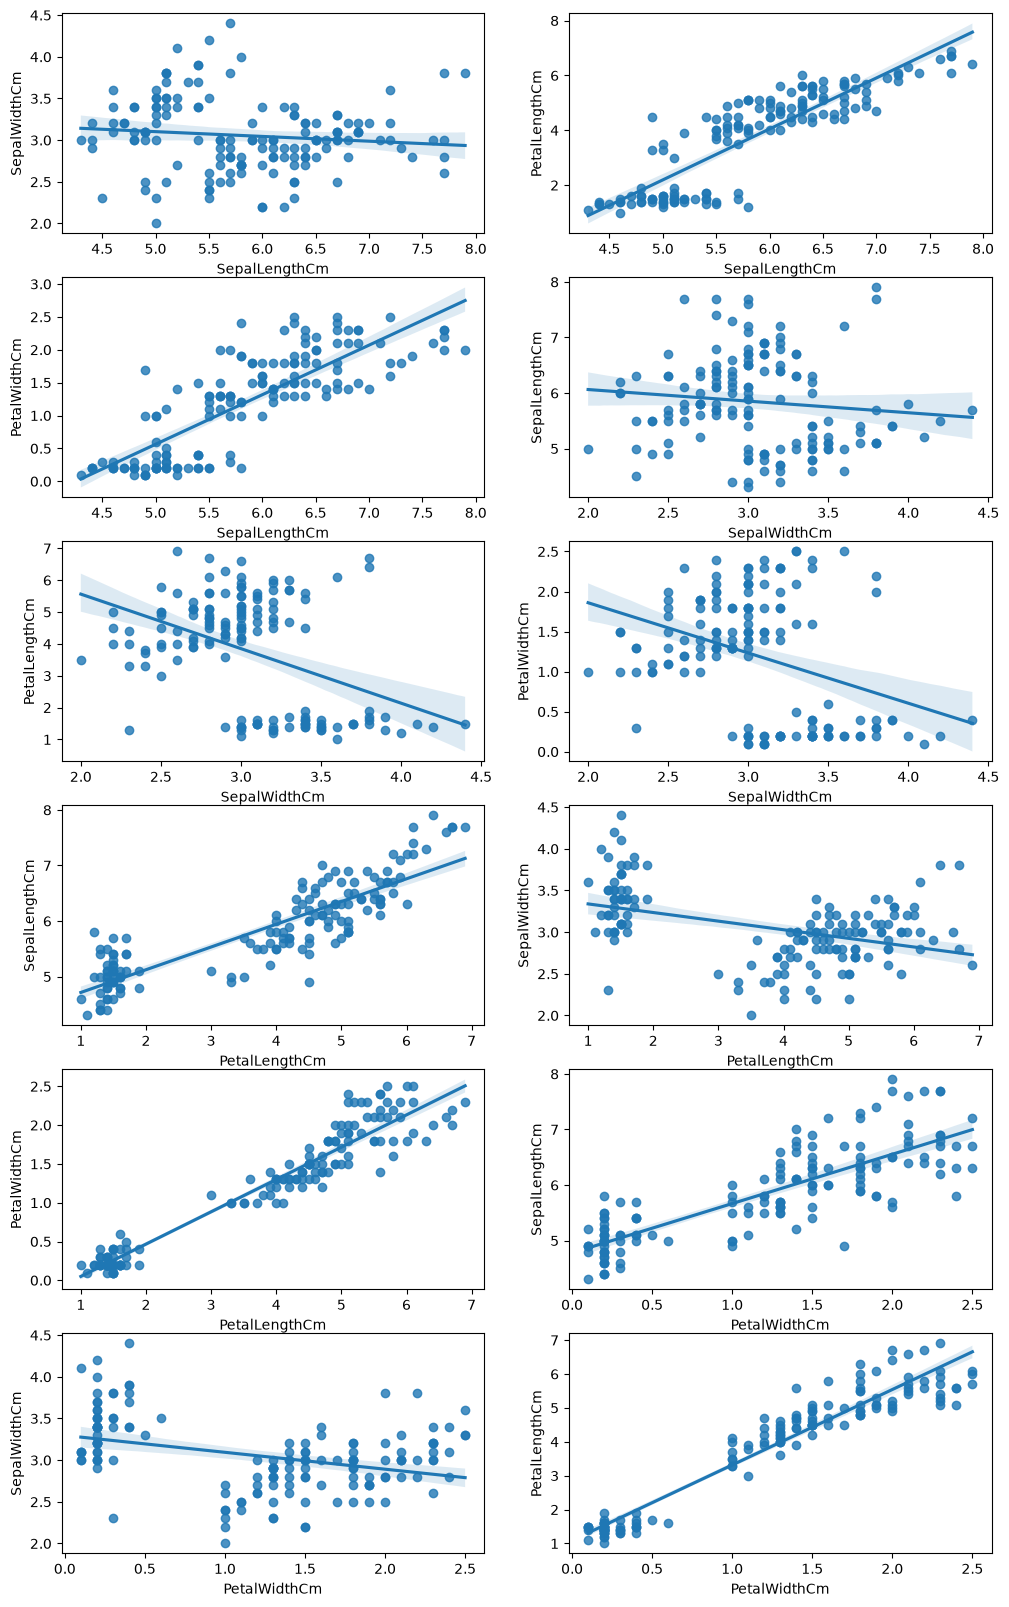

In [36]:
fig, axes = plt.subplots(6,2,figsize=(12,20))
pairs = []
for i in features:
    for j in features:
        if i != j:
            pairs.append([i, j])
            
ax=axes.flat            
for i in range(len(pairs)):
    sns.regplot(x=pairs[i][0],y=pairs[i][1],ax=ax[i],data=df)

plt.show()

## 2. Расчёт ковариации и корреляций (Пирсон)

Таблица ковариации


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
SepalLengthCm,0.685694,-0.039268,1.273682,0.516904
SepalWidthCm,-0.039268,0.188004,-0.321713,-0.117981
PetalLengthCm,1.273682,-0.321713,3.113179,1.296387
PetalWidthCm,0.516904,-0.117981,1.296387,0.582414


Таблица корреляций


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
SepalLengthCm,1.000000,-0.109369,0.871754,0.817954
SepalWidthCm,-0.109369,1.000000,-0.420516,-0.356544
PetalLengthCm,0.871754,-0.420516,1.000000,0.962757
PetalWidthCm,0.817954,-0.356544,0.962757,1.000000


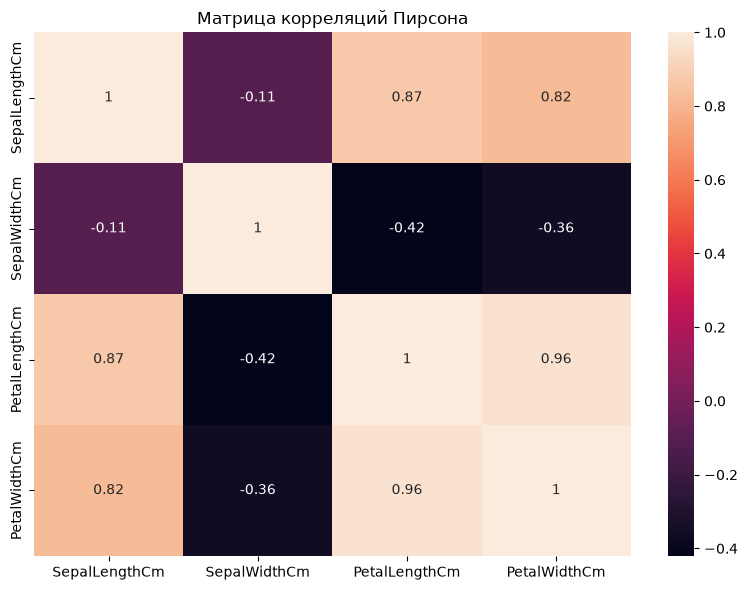

In [37]:
cov = df[features].cov()
print('Таблица ковариации')
display(cov)

corr = df[features].corr(method='pearson')
print('Таблица корреляций')
display(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True)
plt.title('Матрица корреляций Пирсона')
plt.tight_layout()
plt.show()


## 3. Построение матрицы диаграмм рассеяния

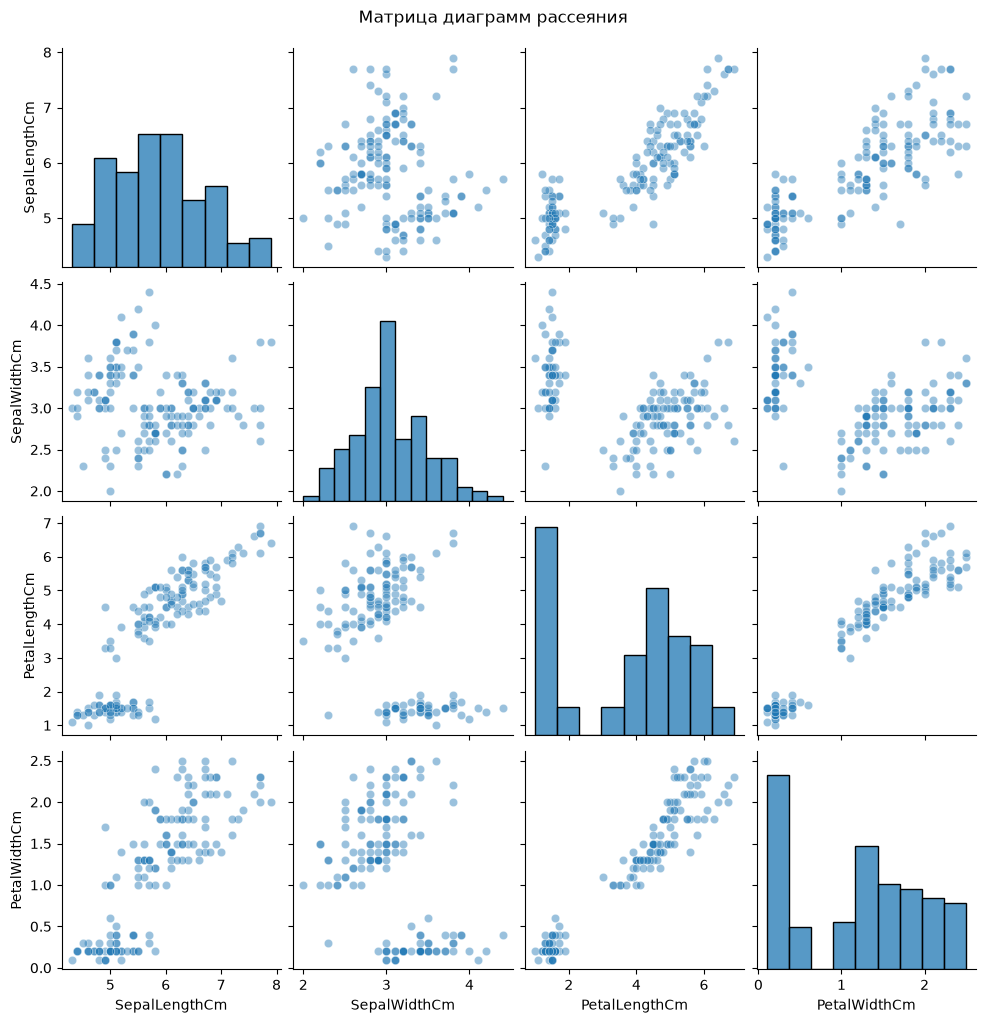

In [38]:
sns.pairplot(df, plot_kws={'alpha': .45})
plt.suptitle('Матрица диаграмм рассеяния', y=1.02)
plt.show()

## 4. Проверка влияния выбросов на корреляцию

In [ ]:
df_4 = df.drop_duplicates(keep='first')
df_without_outliers = df_4.loc[~outlier_mask.loc[df_4.index]]
corr_before = df_4[features].corr()
corr_after = df_without_outliers[features].corr()

comparison = []
for i in range(len(features)):
    for j in range(i + 1, len(features)):
        col1, col2 = features[i], features[j]
        comparison.append({'Пара': f'{col1} — {col2}',
                           'До': corr_before.loc[col1, col2],
                           'После': corr_after.loc[col1, col2],
                           'Изменение': corr_after.loc[col1, col2] - corr_before.loc[col1, col2]})

print(f'После удаления повторов: {len(df_4)} строк; без кандидатов на выбросы: {len(df_without_outliers)}')
display(pd.DataFrame(comparison).round(3))


После удаления повторов: 147 строк; без кандидатов на выбросы: 143


,Пара,До,После,Изменение
0,SepalLengthCm — SepalWidthCm,-0.109,-0.113,-0.004
1,SepalLengthCm — PetalLengthCm,0.871,0.879,0.008
2,SepalLengthCm — PetalWidthCm,0.817,0.822,0.005
3,SepalWidthCm — PetalLengthCm,-0.421,-0.397,0.025
4,SepalWidthCm — PetalWidthCm,-0.356,-0.328,0.028
5,PetalLengthCm — PetalWidthCm,0.962,0.961,-0.001


Таблица показывает, насколько коэффициенты Пирсона чувствительны к крайним наблюдениям. Сравниваются одни и те же пары признаков; отличаются только строки, отмеченные правилом `1.5·IQR`. Если коэффициент меняется, это повод проверить эти цветки, а не сразу удалить их из анализа. Сильная положительная связь длины и ширины лепестка также может частично объясняться различиями между видами.


## 5. Формулирование гипотез о взаимосвязях

Гипотезы для дальнейшей проверки:

1. Длина и ширина лепестка положительно связаны и внутри каждого вида, а не только в общей выборке.
2. По размерам лепестка виды можно различать лучше, чем по размерам чашелистика.
3. Связь между признаками может отличаться у разных видов; для этого следует рассчитать корреляции отдельно по `Species`.

# Часть 6: Сравнительный анализ

## 1. Выбор переменных

Для группировки использую `Species` — номинальный признак.Отдельно рассматриваю `PetalLengthCm`: на графиках длина лепестка заметно различается между видами.


## 2. Построение Box Plot по группам

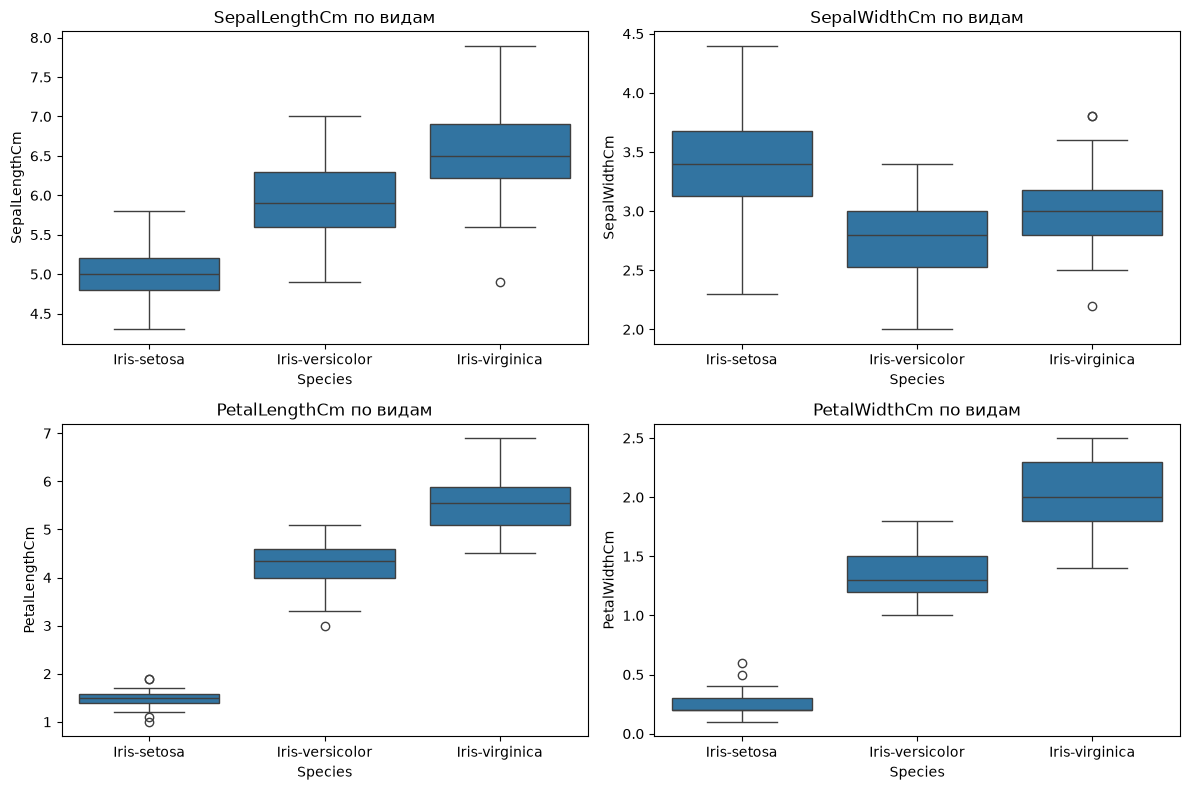

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
ax = axes.flat

for col in range(4):
    sns.boxplot(data=df, x='Species', y=features[col], ax=ax[col])
    ax[col].set_title(f'{features[col]} по видам')
plt.tight_layout()
plt.show()

## 3. Построение CDF для каждой группы

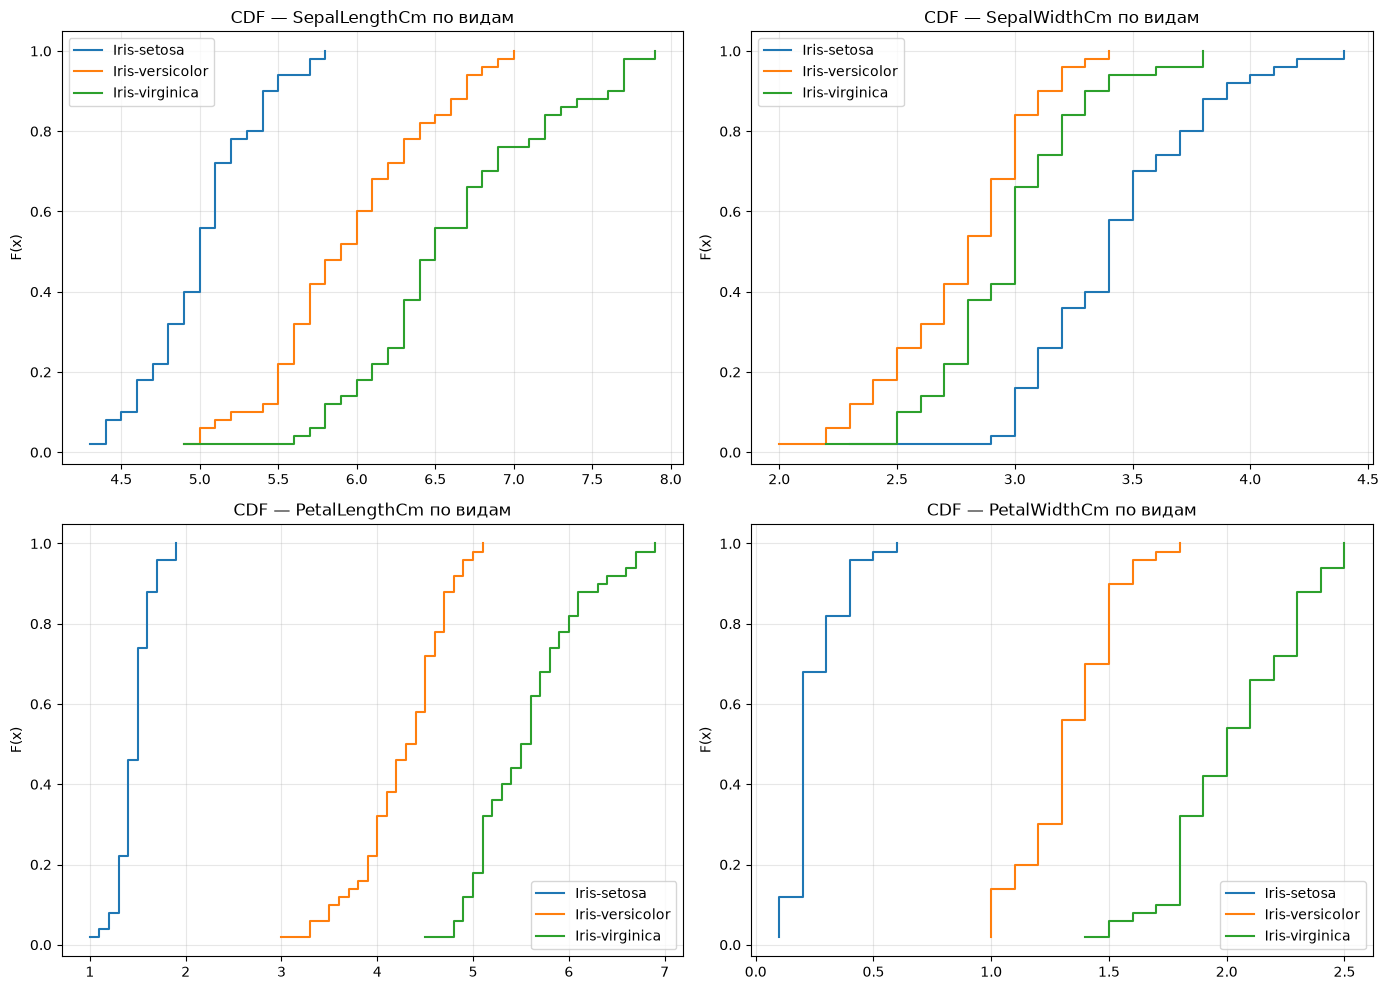

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax = axes.flat

for col in range(4):
    for species, part in df.groupby('Species'):
        values = np.sort(part[features[col]].dropna())
        y = np.arange(1, len(values) + 1) / len(values)
        ax[col].step(values, y, where='post', label=species)
    ax[col].set_title(f'CDF — {features[col]} по видам')
    ax[col].set_ylabel('F(x)')
    ax[col].grid(alpha=0.3)
    ax[col].legend()
    
plt.tight_layout()
plt.show()


## 4. Сравнение медиан и разброса

In [43]:
group_statistics = df.groupby('Species')['PetalLengthCm'].agg(
    Среднее='mean',
    Медиана='median',
    Стандартное_отклонение='std',
    Минимум='min',
    Максимум='max',
    IQR=lambda x: x.quantile(0.75)-x.quantile(0.25),
)
 
group_statistics.round(3)

,Среднее,Медиана,Стандартное_отклонение,Минимум,Максимум,IQR
Species,,,,,,
Iris-setosa,1.464,1.50,0.174,1.0,1.9,0.175
Iris-versicolor,4.260,4.35,0.470,3.0,5.1,0.600
Iris-virginica,5.552,5.55,0.552,4.5,6.9,0.775


In [44]:
df.groupby('Species')[features].agg(['mean', 'median', 'std'])

SepalLengthCm                  SepalWidthCm                   \
                         mean median       std         mean median       std   
Species                                                                        
Iris-setosa             5.006    5.0  0.352490        3.418    3.4  0.381024   
Iris-versicolor         5.936    5.9  0.516171        2.770    2.8  0.313798   
Iris-virginica          6.588    6.5  0.635880        2.974    3.0  0.322497   

                PetalLengthCm                  PetalWidthCm                   
                         mean median       std         mean median       std  
Species                                                                       
Iris-setosa             1.464   1.50  0.173511        0.244    0.2  0.107210  
Iris-versicolor         4.260   4.35  0.469911        1.326    1.3  0.197753  
Iris-virginica          5.552   5.55  0.551895        2.026    2.0  0.274650

## 5. Интерпретация различий на основе графиков

У `Iris-setosa` лепестки заметно короче: медиана длины 1,50 см против 4,35 см у `Iris-versicolor` и 5,55 см у `Iris-virginica`. Разброс тоже увеличивается: IQR длины лепестка равен 0,175, 0,600 и 0,775 см соответственно. На групповых Box Plot это видно по положению ящиков, а на CDF — по сдвигу кривых вправо. Размеры чашелистика разделяют виды слабее: распределения на графиках сильнее пересекаются. Поэтому длина и ширина лепестка выглядят полезными признаками для определения вида, но границы между `versicolor` и `virginica` не абсолютно чёткие.


# Часть 7: Итоговый вывод

Изучены 150 записей с четырьмя количественными размерами и номинальным видом ириса. Пропусков нет; найдены повторяющиеся строки и кандидаты на выбросы по правилу `1.5·IQR`. Эти точки не следует считать ошибочными без проверки исходных измерений.

Проверка 4-Plot показала влияние порядка записи видов и отклонение общего распределения от нормального. Описательные статистики, гистограммы и CDF показывают, что размеры лепестка сильно различаются между видами. Длина и ширина лепестка имеют высокую положительную корреляцию (около 0,963 в общей выборке); сравнение до и после исключения крайних точек приведено выше.

Для следующего этапа можно построить модель определения вида по четырём размерам, прежде всего по размерам лепестка. Перед моделированием стоит проверить связи и распределения внутри каждого вида, а также оценить качество на отдельной проверочной выборке. Выводы относятся к этому набору из 150 цветков.
